In [1]:
import numpy as np
import uproot as up
import matplotlib.pyplot as plt

In [2]:
f=up.open("/home/rice/Projects/DUNE_Opticks/Build_Test/work/Photonlibrary_dune10kt_1x2x6_opticks_v6.root")
f.keys()

['generator;1',
 'generator/PhotonsGenerated;76',
 'generator/PhotonsGenerated;75',
 'largeant;1',
 'largeant/electronsPerStep;1',
 'largeant/photonsPerStep;1',
 'largeant/energyPerStep;1',
 'largeant/stepSize;1',
 'largeant/electronsPerLength;1',
 'largeant/photonsPerLength;1',
 'largeant/electronsPerEDep;1',
 'largeant/photonsPerEDep;1',
 'largeant/electronsVsPhotons;1',
 'pmtresponse;1',
 'pmtresponse/AllPhotons;1',
 'pmtresponse/DetectedPhotons;1',
 'pmtresponse/OpDets;1',
 'pmtresponse/OpDetEvents;1',
 'pmtresponse/PhotonLibraryData;1',
 'pmtresponse/NVoxels;1',
 'pmtresponse/NChannels;1',
 'pmtresponse/MinX;1',
 'pmtresponse/MinY;1',
 'pmtresponse/MinZ;1',
 'pmtresponse/MaxX;1',
 'pmtresponse/MaxY;1',
 'pmtresponse/MaxZ;1',
 'pmtresponse/StepX;1',
 'pmtresponse/StepY;1',
 'pmtresponse/StepZ;1',
 'pmtresponse/NDivX;1',
 'pmtresponse/NDivY;1',
 'pmtresponse/NDivZ;1']

In [3]:
Detected=f["pmtresponse/DetectedPhotons"]
Detected.keys()

['EventID', 'Wavelength', 'OpChannel', 'Time']

In [4]:
optevd=f["pmtresponse/OpDetEvents"]

print(optevd.keys())
print(optevd["CountAll"].array().to_numpy())
print(optevd["CountDetected"].array().to_numpy())
print(optevd["CountDetected"].array().to_numpy()/optevd["CountAll"].array().to_numpy())

['EventID', 'CountAll', 'CountDetected']
[178 215 228 ... 476 492 463]
[178 215 228 ... 476 492 463]
[1. 1. 1. ... 1. 1. 1.]


[]

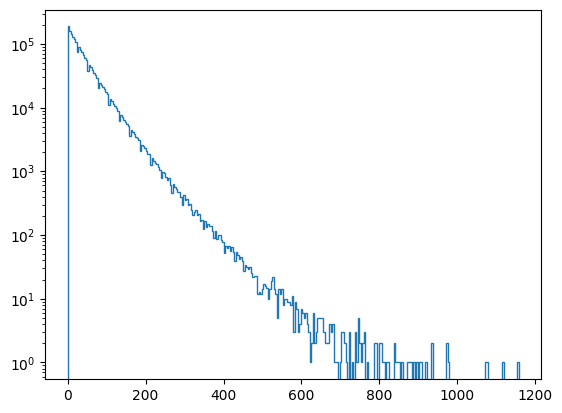

In [5]:
_=plt.hist(Detected['Time'].array().to_numpy(),bins=300,histtype="step")
plt.semilogy()

['X', 'Y', 'Z', 'T', 'PX', 'PY', 'PZ', 'PT', 'EventID']


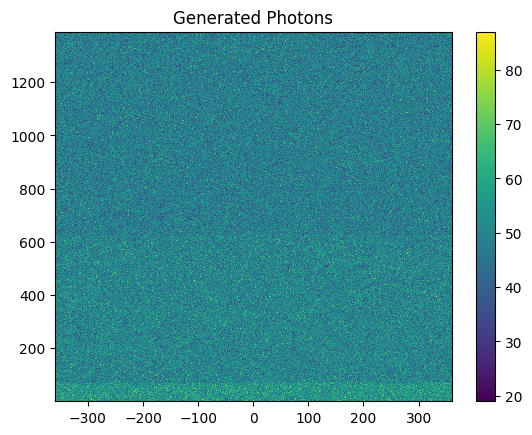

In [6]:
initPhotons=f["generator/PhotonsGenerated"]
print(initPhotons.keys())

_=plt.hist2d(initPhotons["X"].array(library="np"),initPhotons["Z"].array(library="np"),bins=1000)
plt.title("Generated Photons")
plt.colorbar()

In [7]:
AllPhotons=f["pmtresponse/AllPhotons"]
AllPhotons.keys()

['EventID', 'Wavelength', 'OpChannel', 'Time']

In [8]:
# example arrays (replace with your arrays)
det_ids = f["pmtresponse/OpDets/OpChannel"].array(library="np")
counts  = f["pmtresponse/OpDets/CountDetected"].array(library="np")

# ensure 1D
det_ids = np.asarray(det_ids).ravel()
counts  = np.asarray(counts).ravel()

# get unique ids and inverse indices
unique_ids, inv = np.unique(det_ids, return_inverse=True)

# sum counts per unique id
summed_counts = np.bincount(inv, weights=counts)

In [9]:
unique_ids

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

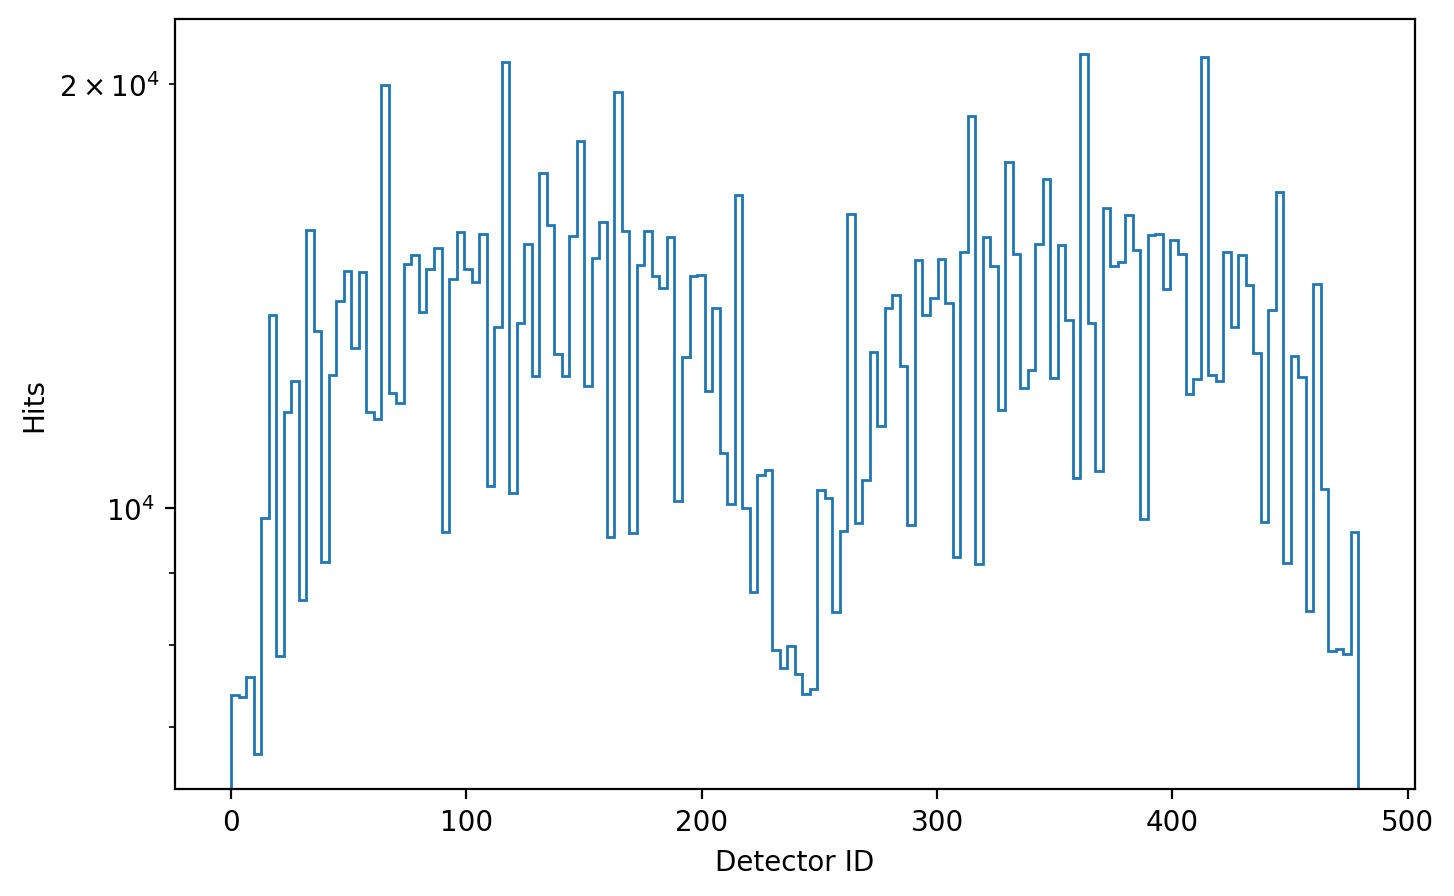

In [10]:
plt.figure(figsize=(8,5),dpi=200)
plt.hist(unique_ids,weights=summed_counts,bins=150,histtype='step')
plt.ylabel("Hits")
plt.xlabel("Detector ID")

plt.semilogy()
plt.show()

In [11]:
counts

array([1, 1, 1, ..., 1, 1, 1], shape=(538238,), dtype=int32)

gridMin=0
gridMax=np.max(OpDet["OpChannel"].array(library="np"))
x=np.linspace(gridMin,gridMax,gridMax)
grid=np.meshgrid((x,x))


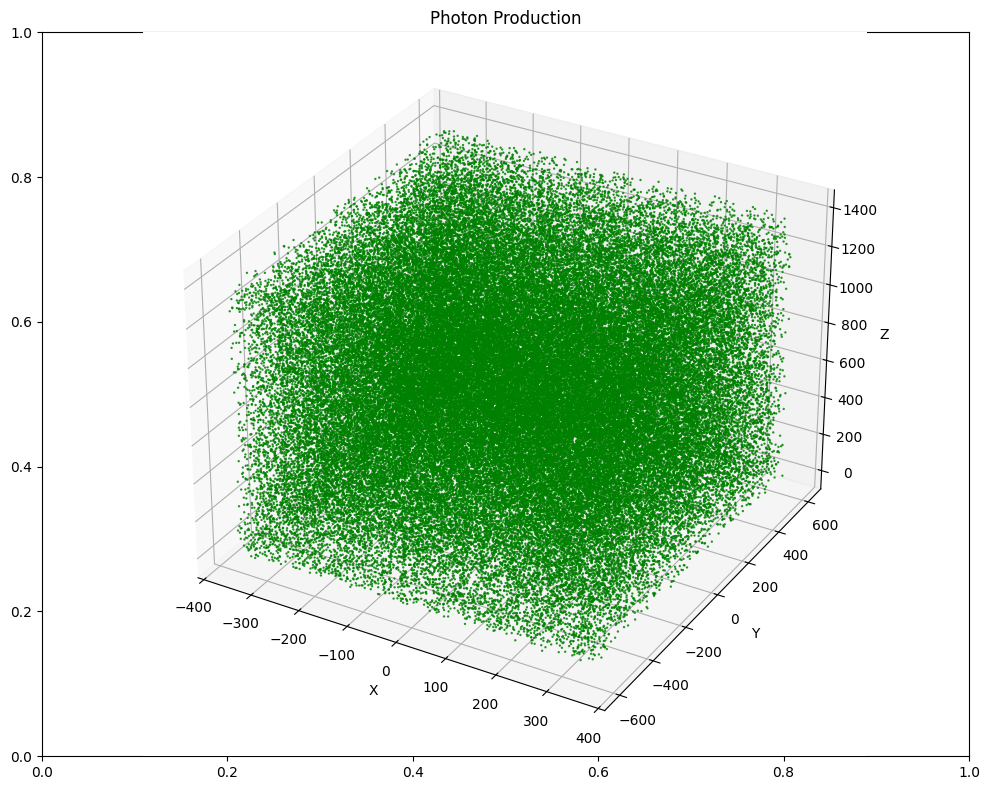

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # registers 3D projection

# load and flatten arrays
x = np.asarray(initPhotons["X"].array(library="np")).ravel()
y = np.asarray(initPhotons["Y"].array(library="np")).ravel()
z = np.asarray(initPhotons["Z"].array(library="np")).ravel()

# mask and downsample
mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
pts = np.vstack((x[mask], y[mask], z[mask])).T
N = 100000  # keep this <= 100k for reasonable speed
if pts.shape[0] > N:
    idx = np.random.choice(pts.shape[0], N, replace=False)
    pts = pts[idx]

fig = plt.figure(figsize=(10,8))
plt.title("Photon Production")
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(pts[:,0], pts[:,1], pts[:,2], s=0.5, color="green", alpha=0.8)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
#plt.colorbar(sc, label='Z')
plt.tight_layout()
plt.savefig('cloud_3d.png', dpi=200)  # offscreen-friendly
plt.show()


In [13]:
print(f["pmtresponse/PhotonLibraryData"].keys())

['Voxel', 'OpChannel', 'Visibility']


In [14]:
Voxel=f["pmtresponse/PhotonLibraryData/Voxel"].array().to_numpy()
OpChannel=f["pmtresponse/PhotonLibraryData/OpChannel"].array().to_numpy()
Visibility=f["pmtresponse/PhotonLibraryData/Visibility"].array().to_numpy()

Text(0, 0.5, 'Visibility')

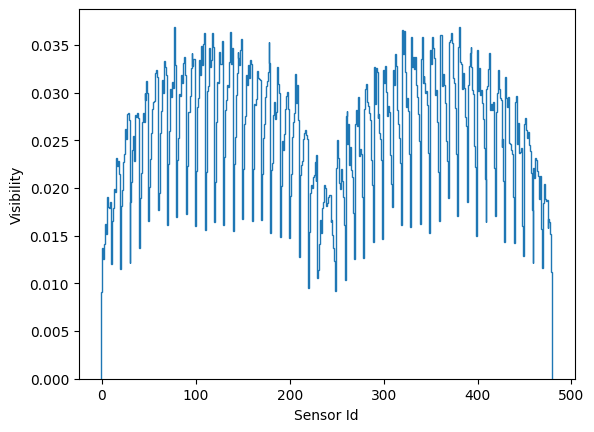

In [15]:

#sensorid=np.arange(np.min(OpChannel),np.max(OpChannel),1)
bins = np.arange(np.min(OpChannel) - 0.5, np.max(OpChannel) + 1.5, 1.0)

_=plt.hist(x=OpChannel, weights=Visibility, histtype="step", bins=bins)
plt.xlabel("Sensor Id")
plt.ylabel("Visibility")

In [16]:
len(Visibility)

61184

In [17]:
len(OpChannel)

61184